<a href="https://colab.research.google.com/github/rmndrs89/advanced-time-series-prediction/blob/main/2_BaselineModel/TensorflowData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.tensorflow.org/guide/data#decoding_image_data_and_resizing_it



In [1]:
from google.colab import drive
drive.mount("/content/drive")
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Mounted at /content/drive


In [3]:
from pathlib import Path
DATASET_PATH = Path("/content/drive/MyDrive/Datasets/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"
train_dataframe = pd.read_csv(DATASET_PATH / "train.csv")
test_dataframe = pd.read_csv(DATASET_PATH / "test.csv")

In [4]:
list_ds = tf.data.Dataset.list_files(str(TRAIN_PATH/'*.npy'))

In [13]:
def parse_file(filename):
    def _load_numpy(f):
        f = f.numpy().decode("utf-8")
        with open(f, 'rb') as f:
            arr = np.load(f)
        features = arr[:, 1:4].astype(np.float32)
        labels = np.argmax(arr[:, 4:], axis=1)
        label = (np.sum(labels) > 0).astype(np.float32)
        return features, label

    features, label = tf.py_function(_load_numpy, [filename], Tout=(tf.float32, tf.float32))
    features.set_shape([None, 3])
    label.set_shape([])
    return features, label

In [16]:
def plot_example(features, label):
    fig, ax = plt.subplots()
    ax.plot(features, lw=2)
    ax.set_title(f"Label: {label}")
    plt.show()

In [17]:
file_path = next(iter(list_ds))
features, label = parse_file(file_path)

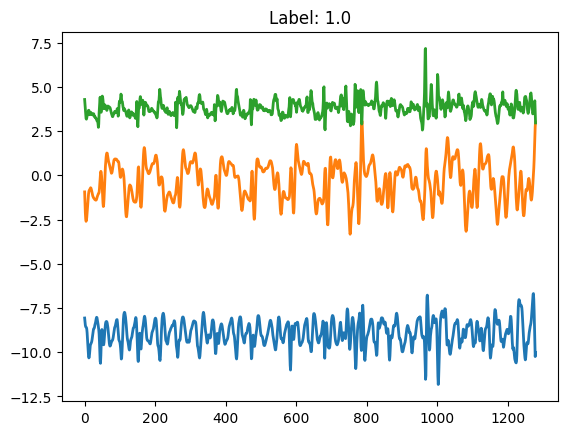

In [18]:
plot_example(features, label)

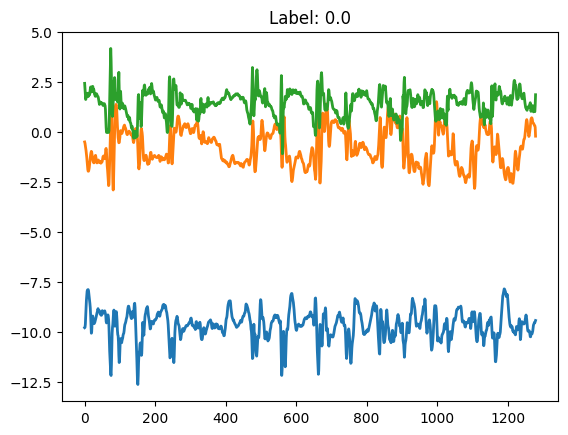

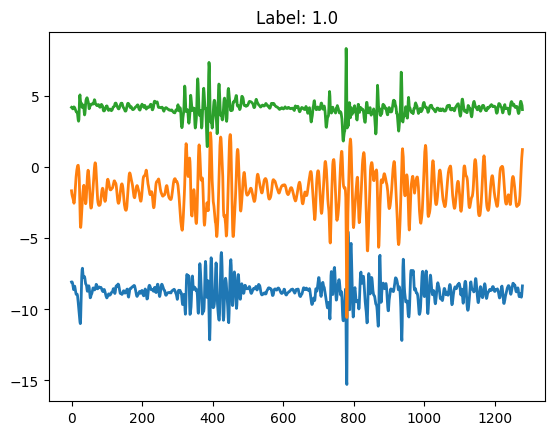

In [19]:
train_ds = list_ds.map(parse_file)

for features, label in train_ds.take(2):
    plot_example(features, label)